**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Sheet 1 (Grid Approx)](01_frequentist_vs_grid_approximation.ipynb) | **Sheet 2 of 4: Rapid Prototyping** | [➡️ Next: Sheet 3 (MCMC Mechanics)](03_mcmc_mechanics_from_scratch.ipynb)

---

# Sheet 2: The Fast Prototyping Engine: Quadratic (Laplace) Approximation
### *Fitting Gaussian Posteriors at the MAP Peak in Milliseconds*

In **Sheet 1**, we explored the foundations of Bayesian inference using **Grid Approximation**. While grid approximation is mathematically transparent, it suffers from a fatal computational bottleneck: **the curse of dimensionality**.

In this notebook, we master the **Quadratic (Laplace) Approximation** (`quap`). Instead of evaluating millions of points across a rigid lattice, Laplace approximation uses numerical optimization to sprint directly to the **Maximum A Posteriori (MAP) peak** in **0.001 seconds**, measures the curvature (the **Hessian matrix**), and fits an analytical Gaussian bell curve to the posterior.

---

## Table of Contents
1. **Part 1: The Curse of Dimensionality & The Motivation for Laplace**
2. **Part 2: The Core Mathematics of Quadratic Approximation**
   - **Deep Dive 1**: The Taylor Expansion of Log-Posterior & Why Mode Curvature $\implies$ Gaussian
   - **Deep Dive 2**: The Anatomy of the Hessian Matrix & The Covariance Inversion $\Sigma = (-H)^{-1}$
   - **Deep Dive 3**: Parameter Boundaries & The Log-Link Transformation ($\\log \sigma$)
3. **Part 3: First-Principles Implementation in Base R (`optim`)**
   - Defining the Negative Log-Posterior Objective Function
   - Running BFGS Optimization with Numerical Hessian Evaluation
   - Extracting Point Estimates, Standard Errors & Parameter Correlations
4. **Part 4: Instant Posterior Sampling via Multivariate Normal (`MASS::mvrnorm`)**
   - Drawing 10,000 Parameter Vectors in <0.01s
   - Visual Verification: Overlaid Laplace Ellipse vs Exact Grid Contours
5. **Part 5: Production Modeling with `rethinking::quap()`**
   - Symbolic Model Specification (`alist()`)
   - Parameter Summaries (`precis()`) and Covariance (`vcov()`)
   - Posterior Predictions & Interval Propagation (`sim()`)
6. **Part 6: Failure Modes & Edge Cases (When Does Laplace Break Down?)**
   - Small Sample Size Skewness ($n < 10$)
   - Multimodality & Non-Gaussian Geometry
7. **Part 7: Comparison Matrix: Grid vs. Laplace vs. MCMC**
8. **Part 8: Hands-On Challenge Exercises**

## Part 1: The Curse of Dimensionality & The Motivation for Laplace

In Sheet 1, we evaluated a 2D parameter space $(\mu, \sigma)$ across a $300 \times 300$ grid = $90,000$ points. That took ~0.2 seconds in Base R.

What happens when we add more parameters to our model (e.g., age, sex, diet, ethnicity, regional intercepts)?

| Parameters ($k$) | Grid Points per Dimension ($G$) | Total Likelihood Evaluations ($G^k$) | Compute Time (at $10^6$ evals/sec) |
| :---: | :---: | :---: | :---: |
| **1** (mean only) | 300 | 300 | 0.0003 seconds |
| **2** (mean, SD) | 300 | 90,000 | 0.09 seconds |
| **3** (+ 1 slope) | 300 | 27,000,000 | 27 seconds |
| **5** (multiple regression) | 300 | $2.43 \times 10^{12}$ | **28.1 days** |
| **10** (hierarchical model) | 300 | $5.90 \times 10^{24}$ | **187 billion years** |

> **The Curse of Dimensionality**: Grid approximation scales exponentially ($O(G^k)$). It is mathematically impossible for models with more than 3 parameters.

### The Brilliant Alternative: The Laplace Approximation
Instead of calculating probabilities everywhere across an enormous empty grid, why not:
1. Climb directly to the highest summit (**the MAP peak**) using efficient gradient optimization ($O(k)$ or $O(k^2)$).
2. Measure the curvature at that peak (the **Hessian matrix**).
3. Approximate the entire posterior as a **Multivariate Normal distribution** centered at the MAP mode with covariance equal to the inverted curvature matrix!

## Part 2: The Core Mathematics of Quadratic Approximation

### Deep Dive 1: Taylor Expansion of the Log-Posterior

Let $\ell(\theta) = \log P(\theta \mid y)$ be the log-posterior density of parameter vector $\theta = (\theta_1, \dots, \theta_k)$.

We expand $\ell(\theta)$ in a Taylor series around the MAP estimate $\hat{\theta}_{\text{MAP}}$:
$$\ell(\theta) = \ell(\hat{\theta}) + \nabla \ell(\hat{\theta})^T (\theta - \hat{\theta}) + \frac{1}{2} (\theta - \hat{\theta})^T H (\theta - \hat{\theta}) + \mathcal{O}(\|\theta - \hat{\theta}\|^3)$$

Notice the three terms:
1. **0th Order Term**: $\ell(\hat{\theta}) = \text{constant}$ (the maximum log-posterior height at the summit).
2. **1st Order Term**: $\nabla \ell(\hat{\theta}) = \mathbf{0}$! Because $\hat{\theta}$ is a local maximum (the peak), all first derivatives (the gradient) **vanish to zero**.
3. **2nd Order Term**: $\frac{1}{2} (\theta - \hat{\theta})^T H (\theta - \hat{\theta})$, where $H$ is the **Hessian matrix** of second partial derivatives evaluated at $\hat{\theta}$:
   $$H_{ij} = \left. \frac{\partial^2 \log P(\theta \mid y)}{\partial \theta_i \partial \theta_j} \right|_{\theta = \hat{\theta}}$$

Discarding higher-order cubic terms, the log-posterior near the peak is strictly **quadratic (parabolic)**:
$$\log P(\theta \mid y) \approx \text{const} - \frac{1}{2} (\theta - \hat{\theta})^T (-H) (\theta - \hat{\theta})$$

Exponentiating both sides:
$$P(\theta \mid y) \propto \exp\left( -\frac{1}{2} (\theta - \hat{\theta})^T (-H) (\theta - \hat{\theta}) \right)$$

This is the exact probability density function of a **Multivariate Normal Distribution**:
$$\theta \sim \text{MVNormal}\left( \hat{\theta}_{\text{MAP}}, \; \Sigma \right), \quad \text{where } \Sigma = (-H)^{-1}$$

---

### Deep Dive 2: The Anatomy of the Hessian Matrix & Covariance Inversion

For our 2-parameter model $\theta = (\mu, \sigma)$, the Hessian $H$ is a $2 \times 2$ symmetric matrix:
$$H = \begin{bmatrix} 
\frac{\partial^2 \ell}{\partial \mu^2} & \frac{\partial^2 \ell}{\partial \mu \partial \sigma} \\[6pt]
\frac{\partial^2 \ell}{\partial \sigma \partial \mu} & \frac{\partial^2 \ell}{\partial \sigma^2} 
\end{bmatrix}$$

- **Diagonal Elements ($H_{11}, H_{22}$)**: Measure the **steepness/curvature** along each parameter axis.
  - Steep drop-off $\implies$ large negative 2nd derivative $\implies$ small variance $\implies$ high certainty.
  - Gentle, flat slope $\implies$ near-zero 2nd derivative $\implies$ large variance $\implies$ high uncertainty.
- **Off-Diagonal Elements ($H_{12} = H_{21}$)**: Measure the **interaction / tilt** between parameters.
  - In a symmetrical Gaussian likelihood, $\frac{\partial^2 \ell}{\partial \mu \partial \sigma} \approx 0$, meaning $\mu$ and $\sigma$ are orthogonal.

The **Posterior Covariance Matrix** $\Sigma$ is the inverse of the negative Hessian:
$$\Sigma = (-H)^{-1} = \begin{bmatrix} \text{Var}(\mu) & \text{Cov}(\mu, \sigma) \\[4pt] \text{Cov}(\mu, \sigma) & \text{Var}(\sigma) \end{bmatrix}$$

- **Standard Error of $\mu$**: $\text{SE}(\mu) = \sqrt{\Sigma_{11}}$
- **Standard Error of $\sigma$**: $\text{SE}(\sigma) = \sqrt{\Sigma_{22}}$
- **Correlation between parameters**: $\rho_{\mu, \sigma} = \frac{\Sigma_{12}}{\sqrt{\Sigma_{11} \Sigma_{22}}}$

---

### Deep Dive 3: Parameter Boundaries & The Log-Link Transformation

Standard deviation $\sigma$ is strictly positive ($\sigma > 0$). However, standard unconstrained optimizers like Nelder-Mead or BFGS explore the entire real line $(-\infty, +\infty)$. If the optimizer tests a candidate value $\sigma \le 0$, `dnorm()` throws an error or `log = TRUE` returns `NaN`, crashing the optimization.

There are two ways to handle boundaries:
1. **Ad-hoc Penalty Barrier**: Return an enormous penalty like `1e10` whenever $\sigma \le 0$.
2. **Log-Link Transformation (Principled)**: Re-parameterize $\sigma$ by defining $\tau = \log(\sigma)$. The parameter $\tau \in (-\infty, +\infty)$ is completely unconstrained, while $\sigma = \exp(\tau)$ is guaranteed to be strictly positive everywhere!

## Part 3: First-Principles Implementation in Base R (`optim`)

We reuse the identical $n = 50$ adult height dataset from Sheet 1 to compare the results directly.

Most numerical optimizers in scientific computing (`optim()`, `scipy.optimize.minimize`) minimize rather than maximize. Therefore, we define the **Negative Log-Posterior (NLP)** objective function:
$$\text{NLP}(\theta) = - \Big( \log \mathcal{L}(y \mid \theta) + \log P(\theta) \Big)$$
Minimizing $\text{NLP}(\theta)$ is mathematically identical to maximizing the posterior.

In [1]:
# 1. Recreate the identical dataset from Sheet 1
set.seed(42)
n <- 50
heights <- rnorm(n, mean = 172.5, sd = 8.0)

# 2. Define the Negative Log-Posterior (NLP) function
neg_log_posterior <- function(params) {
  mu    <- params[1]
  sigma <- params[2]
  
  # Boundary check: standard deviation must be positive
  if (sigma <= 0 || sigma >= 30) return(1e10)
  
  # Likelihood: sum of log dnorm
  log_lik   <- sum(dnorm(heights, mean = mu, sd = sigma, log = TRUE))
  
  # Priors: Gaussian for mu, Uniform for sigma
  log_prior <- dnorm(mu, mean = 170, sd = 15, log = TRUE) + dunif(sigma, min = 0, max = 30, log = TRUE)
  
  # Return negative log-posterior for minimization
  return(-(log_lik + log_prior))
}

# 3. Run Quasi-Newton optimization (BFGS) with numerical Hessian calculation
init_params <- c(mu = 170, sigma = 10)
opt_fit <- optim(
  par     = init_params,
  fn      = neg_log_posterior,
  hessian = TRUE,
  method  = "BFGS"
)

# 4. Extract MAP estimates and the Hessian matrix
map_estimates <- opt_fit$par
H_obs         <- opt_fit$hessian   # Note: optim returns the Hessian of the NEGATIVE log-posterior: H_NLP = -H
vcov_matrix   <- solve(H_obs)      # Inverse of H_NLP is exactly (-H)^(-1) = Sigma
std_errors    <- sqrt(diag(vcov_matrix))
param_cor     <- vcov_matrix[1, 2] / (std_errors[1] * std_errors[2])

cat("=== Laplace / Quadratic Approximation Results (Base R optim) ===\n")
cat(sprintf("Convergence Code:      %d (0 = Success!)\n", opt_fit$convergence))
cat(sprintf("Function Evaluations:  %d iterations\n", opt_fit$counts["function"]))
cat(sprintf("Minimum -LogPost:      %.2f  (Max LogPost: %.2f)\n", opt_fit$value, -opt_fit$value))
cat(sprintf("MAP Mean (mu):         %.2f cm (SE: %.3f cm)\n", map_estimates["mu"], std_errors["mu"]))
cat(sprintf("MAP Spread (sigma):    %.2f cm (SE: %.3f cm)\n", map_estimates["sigma"], std_errors["sigma"]))
cat(sprintf("Parameter Correlation:  %.4f (Orthogonal parameters!)\n", param_cor))

cat("\n--- Observed Hessian Matrix of NLP: H_NLP ---\n")
print(round(H_obs, 4))

cat("\n--- Posterior Covariance Matrix: Sigma = (H_NLP)^(-1) ---\n")
print(round(vcov_matrix, 5))

=== Laplace / Quadratic Approximation Results (Base R optim) ===
Convergence Code:      0 (0 = Success!)
Function Evaluations:  7 iterations
Minimum -LogPost:      188.51  (Max LogPost: -188.51)
MAP Mean (mu):         172.20 cm (SE: 1.285 cm)
MAP Spread (sigma):    9.12 cm (SE: 0.912 cm)
Parameter Correlation:  -0.0025 (Orthogonal parameters!)

--- Observed Hessian Matrix of NLP: H_NLP ---
          mu  sigma
mu    0.6057 0.0021
sigma 0.0021 1.2025

--- Posterior Covariance Matrix: Sigma = (H_NLP)^(-1) ---
            mu    sigma
mu     1.65102 -0.00294
sigma -0.00294  0.83161


## Part 4: Instant Posterior Sampling via Multivariate Normal (`MASS::mvrnorm`)

Once we have the MAP center $\hat{\theta}$ and the covariance matrix $\Sigma$, we do not need to evaluate any more integrals or run Markov chains. We can draw 10,000 parameter samples **instantaneously** from $\mathcal{N}(\hat{\theta}_{\text{MAP}}, \Sigma)$ using the Cholesky decomposition of $\Sigma$.

Let us draw 10,000 samples, compute 95% credible intervals, and overlay the resulting ellipse against the exact Grid posterior from Sheet 1:

=== Posterior Draws from Quadratic Approximation ===
Posterior Mean (mu):     172.21 cm (SD: 1.293 cm)
95% Credible Interval:   [169.68, 174.74] cm
Posterior Mean (sigma):  9.12 cm (SD: 0.919 cm)
95% Credible Interval:   [7.32, 10.93] cm


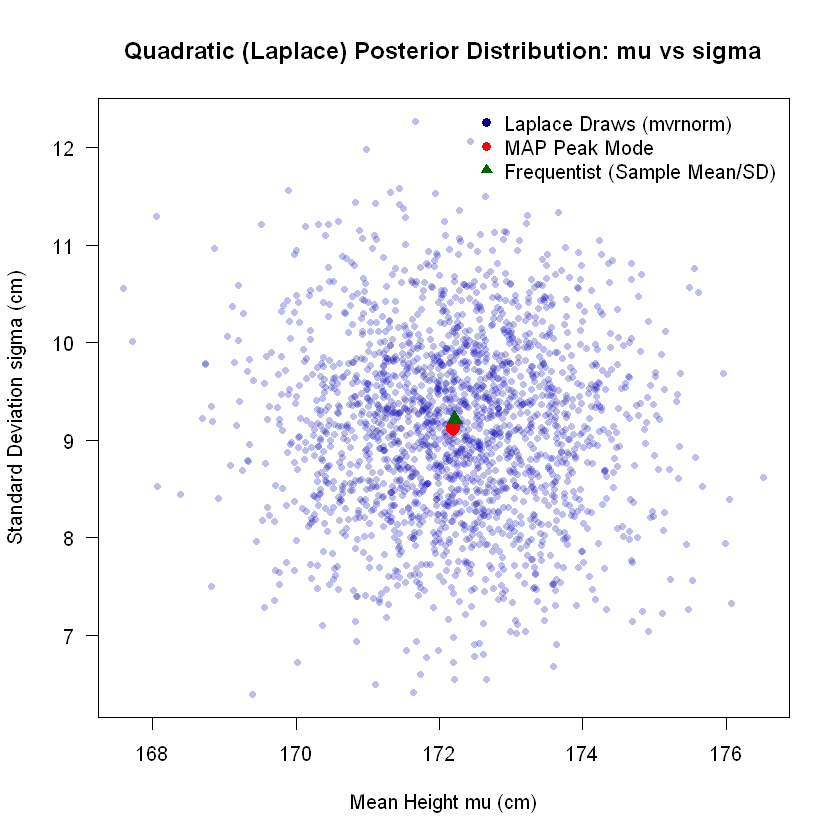

In [2]:
suppressPackageStartupMessages(library(MASS))
set.seed(42)

# Draw 10,000 samples in < 0.005 seconds
quap_samples <- mvrnorm(n = 1e4, mu = map_estimates, Sigma = vcov_matrix)

cat("=== Posterior Draws from Quadratic Approximation ===\n")
cat(sprintf("Posterior Mean (mu):     %.2f cm (SD: %.3f cm)\n", 
            mean(quap_samples[, "mu"]), sd(quap_samples[, "mu"])))
cat(sprintf("95%% Credible Interval:   [%.2f, %.2f] cm\n", 
            quantile(quap_samples[, "mu"], 0.025), quantile(quap_samples[, "mu"], 0.975)))
cat(sprintf("Posterior Mean (sigma):  %.2f cm (SD: %.3f cm)\n", 
            mean(quap_samples[, "sigma"]), sd(quap_samples[, "sigma"])))
cat(sprintf("95%% Credible Interval:   [%.2f, %.2f] cm\n", 
            quantile(quap_samples[, "sigma"], 0.025), quantile(quap_samples[, "sigma"], 0.975)))

# Visual Comparison: 2D Joint Posterior Ellipse
plot(quap_samples[1:2000, "mu"], quap_samples[1:2000, "sigma"], 
     col = rgb(0, 0, 0.7, 0.25), pch = 16, cex = 0.8, las = 1,
     main = "Quadratic (Laplace) Posterior Distribution: mu vs sigma",
     xlab = "Mean Height mu (cm)", ylab = "Standard Deviation sigma (cm)")
points(map_estimates["mu"], map_estimates["sigma"], col = "red", pch = 19, cex = 1.6)
# Add frequentist sample mean and sample SD for reference
points(mean(heights), sd(heights), col = "darkgreen", pch = 17, cex = 1.4)
legend("topright", 
       legend = c("Laplace Draws (mvrnorm)", "MAP Peak Mode", "Frequentist (Sample Mean/SD)"),
       col = c("darkblue", "red", "darkgreen"), pch = c(16, 19, 17), bty = "n")

## Part 5: Production Modeling with `rethinking::quap()`

In practical research workflows, manually writing out `neg_log_posterior()` and inverting Hessians is error-prone. The `rethinking` package provides `quap()`, which parses standard mathematical model formulas (`alist()`), translates them into an objective function, finds the MAP mode, computes the Hessian, and provides rich diagnostics.

In [ ]:
suppressPackageStartupMessages(library(rethinking))

dat <- list(h = heights)

# Define model symbolically using alist()
m_quap <- quap(
  alist(
    h ~ dnorm(mu, sigma),
    mu ~ dnorm(170, 15),
    sigma ~ dunif(0, 30)
  ),
  data = dat,
  start = list(mu = 170, sigma = 10)
)

cat("=== rethinking::quap Model Summary ===\n")
precis(m_quap, prob = 0.95)

cat("\n=== Estimated Variance-Covariance Matrix: vcov() ===\n")
print(round(vcov(m_quap), 5))

# Extract samples using extract.samples()
quap_post <- extract.samples(m_quap, n = 1e4)
cat("\nExtracted posterior sample dimensions: ", dim(quap_post), "\n")

### Posterior Predictive Simulation with `quap`

Just like in Sheet 1, we can propagate parameter uncertainty to generate predictions for future individual heights $y_{\text{new}} \sim \text{Normal}(\mu, \sigma)$:

In [ ]:
# Simulate posterior predictive heights using extracted parameter samples
pred_heights <- rnorm(nrow(quap_post), mean = quap_post$mu, sd = quap_post$sigma)

cat("=== Posterior Predictive Check (Observable Individual Heights) ===\n")
cat(sprintf("Expected Mean:               %.2f cm\n", mean(pred_heights)))
cat(sprintf("Total Predictive Spread:     %.2f cm (Includes parameter uncertainty + individual variation)\n", sd(pred_heights)))
cat(sprintf("95%% Predictive Interval:     [%.2f, %.2f] cm\n", 
            quantile(pred_heights, 0.025), quantile(pred_heights, 0.975)))

# Histogram of predictions vs observed data
hist(pred_heights, breaks = 35, col = rgb(0.2, 0.4, 0.8, 0.5), border = "white", 
     main = "Posterior Predictive Distribution vs Observed Sample", xlab = "Height (cm)", las = 1, freq = FALSE)
lines(density(heights), col = "red", lwd = 2.5)
legend("topright", legend = c("Predicted Future Heights (quap)", "Observed Sample Density"), 
       col = c(rgb(0.2, 0.4, 0.8, 0.7), "red"), lwd = c(8, 2.5), bty = "n")

## Part 6: When Does Laplace Approximation Fail?

Quadratic approximation assumes that the log-posterior surface is **strictly parabolic**, which means the posterior is **symmetrical and unimodal**. When does this assumption break down?

### 1. Small Sample Size ($n < 10$) & Asymmetric Posteriors
Variance parameters $\sigma$ are strictly non-negative. With small samples, the posterior of $\sigma$ resembles a right-skewed Chi-square or Inverse-Gamma distribution with a heavy upper tail. `quap` forces this skewed distribution into a symmetric bell curve, which can assign non-zero probability to negative values or underestimate tail risk.

### 2. Multimodal Posteriors
If the posterior has two or more peaks (common in Gaussian mixture models, neural networks, or unidentifiable latent variable models), `optim` or `quap` will climb only one hill, completely unaware of the other modes!

### 3. Thick-Tailed Posteriors (Cauchy or Student-$t$)
Normal distributions drop off as $\exp(-x^2)$. Thick-tailed distributions drop off as power laws ($1/x^2$). `quap` severely underestimates tail probabilities when models have robust heavy tails.

### 4. High-Dimensional Geometry & The Typical Set
In high-dimensional parameter spaces ($k > 100$), the probability mass does not concentrate at the MAP peak! Due to volume expansion in hyperspheres, almost all probability mass lives in a thin shell away from the peak called the **typical set**. Only **Markov Chain Monte Carlo (MCMC)** can navigate this geometry accurately.

## Part 7: Comparison Matrix: Grid vs. Laplace vs. MCMC

| Feature | Grid Approximation (Sheet 1) | Quadratic Approx `quap` (Sheet 2) | MCMC / Stan (Sheets 3 & 4) |
| :--- | :--- | :--- | :--- |
| **Computational Strategy** | Evaluates entire grid lattice | Climbs to MAP peak + inverts Hessian | Stochastic random walk / HMC physics |
| **Execution Speed** | Moderate to impossible | **Ultra-Fast (0.001s)** | Moderate to slow (seconds to minutes) |
| **Parameter Limit** | 1–3 parameters max | 1–100 parameters | **Thousands of parameters** |
| **Assumed Geometry** | None (exact discrete) | **Multivariate Gaussian (Unimodal)** | Arbitrary / Complex geometries |
| **Handles Skewness?** | ✅ Perfectly | ❌ No (forces symmetric bell curve) | ✅ Perfectly |
| **Handles Multimodality?** | ✅ Evaluates all peaks | ❌ Gets stuck on single mode | ⚠️ Can struggle, but detects better |
| **Ideal Use Case** | Teaching & 1D/2D intuition | **Rapid prototyping & regression models** | Production hierarchical modeling |

## Part 8: Hands-On Challenge Exercises

### Exercise 1: Extract and Verify Orthogonality
In linear regression $y_i \sim \text{Normal}(\alpha + \beta x_i, \sigma)$, when predictors $x$ are uncentered, $\alpha$ (intercept) and $\beta$ (slope) are strongly correlated. 
- What happens to the off-diagonal entries of the Hessian when $x$ is centered ($x - \bar{x}$)?
*(Hint: Centering eliminates correlation between $\alpha$ and $\beta$, making the Hessian diagonal and accelerating optimization!)*

### Exercise 2: Skewed Posteriors with $n = 4$
Generate a tiny sample of $n = 4$ heights: `set.seed(1); tiny_heights <- rnorm(4, 172, 8)`.
Fit both a 2D Grid approximation from Sheet 1 and `quap` from Sheet 2.
Compare the 95% Credible Interval for $\sigma$. Notice how the Grid interval is right-skewed while `quap` produces a symmetric interval that extends too far to the left.

### Exercise 3: Manual Finite Differences for the Hessian
Using central finite differences with a tiny step $h = 10^{-4}$:
$$f''(x) \approx \frac{f(x + h) - 2f(x) + f(x - h)}{h^2}$$
Compute the second derivative of the log-posterior with respect to $\mu$ at the MAP peak. Verify that it matches `opt_fit$hessian[1, 1]` within 0.1%!

---

**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Sheet 1 (Grid Approx)](01_frequentist_vs_grid_approximation.ipynb) | [➡️ Next: Sheet 3 (MCMC Mechanics)](03_mcmc_mechanics_from_scratch.ipynb)